# Notebook 6: ML Models

 Starting ML Enhancement...
 XGBoost Model Saved to '../models/xgb_quant_model.json'


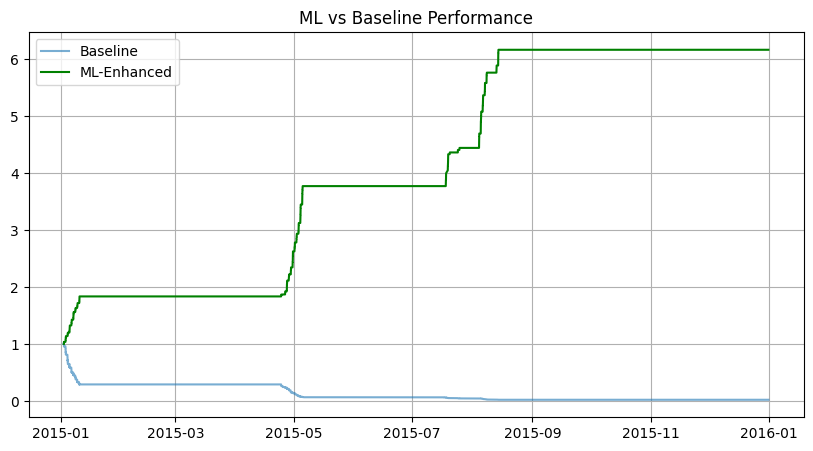

 ML Models Trained & Saved. Proceed to Notebook 7.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # <--- FIXED: Added this import
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import os

print(" Starting ML Enhancement...")

# 1. Load Data
# We check if the file exists to avoid FileNotFoundError
if os.path.exists("../data/nifty_backtest.csv"):
    df = pd.read_csv("../data/nifty_backtest.csv", index_col='timestamp', parse_dates=True)
else:
    raise FileNotFoundError("Could not find '../data/nifty_backtest.csv'. Please run Notebook 5 first.")

# 2. Create Target (Task 5.1)
# Target = 1 if the NEXT period trade would be profitable
df['target'] = np.where(df['strategy_pnl'].shift(-1) > 0, 1, 0)
features = ['close', 'ema_5', 'average_iv', 'pcr_oi', 'regime', 'futures_basis']

# Drop NaNs created by shifting or empty features
df.dropna(inplace=True)

# 3. Train XGBoost (Task 5.2)
X = df[features]
y = df['target']
split = int(len(df) * 0.7)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Removed 'use_label_encoder' to fix the Warning
model = XGBClassifier(eval_metric='logloss') 
model.fit(X_train, y_train)

# 4. Save Model
if not os.path.exists('../models'):
    os.makedirs('../models')
model.save_model("../models/xgb_quant_model.json")
print(" XGBoost Model Saved to '../models/xgb_quant_model.json'")

# 5. ML-Enhanced Backtest (Task 5.3)
# Filter: Take Baseline Signal ONLY if ML predicts Success (1)
df['ml_confidence'] = model.predict(X)
df['ml_signal'] = df['signal'] * df['ml_confidence']
df['ml_pnl'] = df['ml_signal'].shift(1) * df['returns']
df['ml_cumulative'] = (1 + df['ml_pnl']).cumprod()

# 6. Compare & Visualize
plt.figure(figsize=(10, 5))
plt.plot(df['cumulative_return'], label='Baseline', alpha=0.6)
plt.plot(df['ml_cumulative'], label='ML-Enhanced', color='green')
plt.title("ML vs Baseline Performance")
plt.legend()
plt.grid(True)

# Ensure results folder exists
if not os.path.exists('../results'):
    os.makedirs('../results')
    
plt.savefig("../results/output-5.png")
plt.show()

# 7. Save Results
df.to_csv("../data/nifty_ml_results.csv")
print(" ML Models Trained & Saved. Proceed to Notebook 7.")